# Baseline Results Summary

Summarises results and progress for the four baseline models built so far: Chapman-Richards,
average-by-age, linear regression, and random forest. All fitted on the training split only
(`plot_level_split`, 60/20/20) and evaluated on the held-out test split, for both the 4survey
and 6survey cohorts.

This notebook only reads already-saved results from `outputs/` (`metrics.json`,
`predictions.csv`) — it does not refit or re-evaluate anything. To regenerate the underlying
results, run `python -m models.baselines.run_baselines` then `python -m models.baselines.evaluate_baselines`.

**On loss functions:** none of these four models need one, and none are shown here. "Loss
function" in the usual sense (an iterative training loop with a loss curve to check convergence
over epochs) only applies to models trained by gradient descent. None of these four are:
Chapman-Richards and linear regression are single least-squares solves, average-by-age is a
groupby-mean with no optimisation step at all, and random forest builds trees by greedy variance
reduction, not epochs. There is nothing to plot. This becomes relevant again once the DNN/PINN
work starts.

In [1]:
# Purpose: Make the models/ package importable from this notebook.
# Key logic: Walk upward from the current folder until a folder containing
# both README.md and data/ is found — that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from models.common.plotting import plot_error_by_age, plot_predicted_vs_observed, plot_residuals

pd.set_option("display.max_columns", 50)

COHORTS = ["4survey", "6survey"]
MODEL_NAMES = ["chapman_richards", "average_by_age", "linear_baseline", "rf_baseline"]
MODEL_COLORS = {
    "chapman_richards": "#1f77b4",
    "average_by_age": "#ff7f0e",
    "linear_baseline": "#2ca02c",
    "rf_baseline": "#d62728",
}

## 1. Load saved results

One `metrics.json` and one `predictions.csv` per model per cohort, all already produced by
`models/baselines/`.

In [3]:
def load_metrics(model_name, cohort):
    path = project_root / "outputs" / model_name / cohort / "metrics.json"
    with open(path) as f:
        return json.load(f)


def load_predictions(model_name, cohort):
    path = project_root / "outputs" / model_name / cohort / "predictions.csv"
    return pd.read_csv(path)


all_metrics = {}
all_predictions = {}

for cohort in COHORTS:
    for model_name in MODEL_NAMES:
        all_metrics[(model_name, cohort)] = load_metrics(model_name, cohort)
        all_predictions[(model_name, cohort)] = load_predictions(model_name, cohort)

print(f"Loaded metrics and predictions for {len(MODEL_NAMES)} models x {len(COHORTS)} cohorts")

Loaded metrics and predictions for 4 models x 2 cohorts


## 2. Summary table: all models, both cohorts, all metrics

Test-split metrics only (none of these models ever see the test split during fitting).

In [4]:
summary_rows = []
for cohort in COHORTS:
    for model_name in MODEL_NAMES:
        m = all_metrics[(model_name, cohort)]
        summary_rows.append({
            "cohort": cohort,
            "model": model_name,
            "n_test_rows": m["n"],
            "MAE": m["mae"],
            "RMSE": m["rmse"],
            "MSE": m["mse"],
            "R2": m["r2"],
            "MRE": m["mre"],
            "Accuracy_pct": m["accuracy_pct"],
            "Bias": m["bias"],
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.format({
    "MAE": "{:.4f}", "RMSE": "{:.4f}", "MSE": "{:.4f}", "R2": "{:.4f}",
    "MRE": "{:.4f}", "Accuracy_pct": "{:.2f}", "Bias": "{:.4f}",
}))

,cohort,model,n_test_rows,MAE,RMSE,MSE,R2,MRE,Accuracy_pct,Bias
0,4survey,chapman_richards,49597,5.0276,6.3858,40.7782,0.3783,0.3151,68.49,-0.0102
1,4survey,average_by_age,49597,4.8868,6.2172,38.6540,0.4107,0.3066,69.34,0.0081
2,4survey,linear_baseline,49597,4.0929,5.2536,27.5998,0.5792,0.2291,77.09,0.0012
3,4survey,rf_baseline,49597,3.3500,4.5827,21.0007,0.6798,0.1839,81.61,-0.0016
4,6survey,chapman_richards,13955,3.0691,4.3876,19.2509,0.5540,0.1605,83.95,-0.1708
5,6survey,average_by_age,13955,2.7349,3.8336,14.6968,0.6595,0.1440,85.60,-0.0193
6,6survey,linear_baseline,13955,3.2735,4.3017,18.5048,0.5713,0.1694,83.06,-0.0600
7,6survey,rf_baseline,13955,2.6368,3.6248,13.1393,0.6956,0.1312,86.88,-0.0066


## 3. Model comparison bar charts

Same numbers as the table above, easier to compare at a glance across models and cohorts.

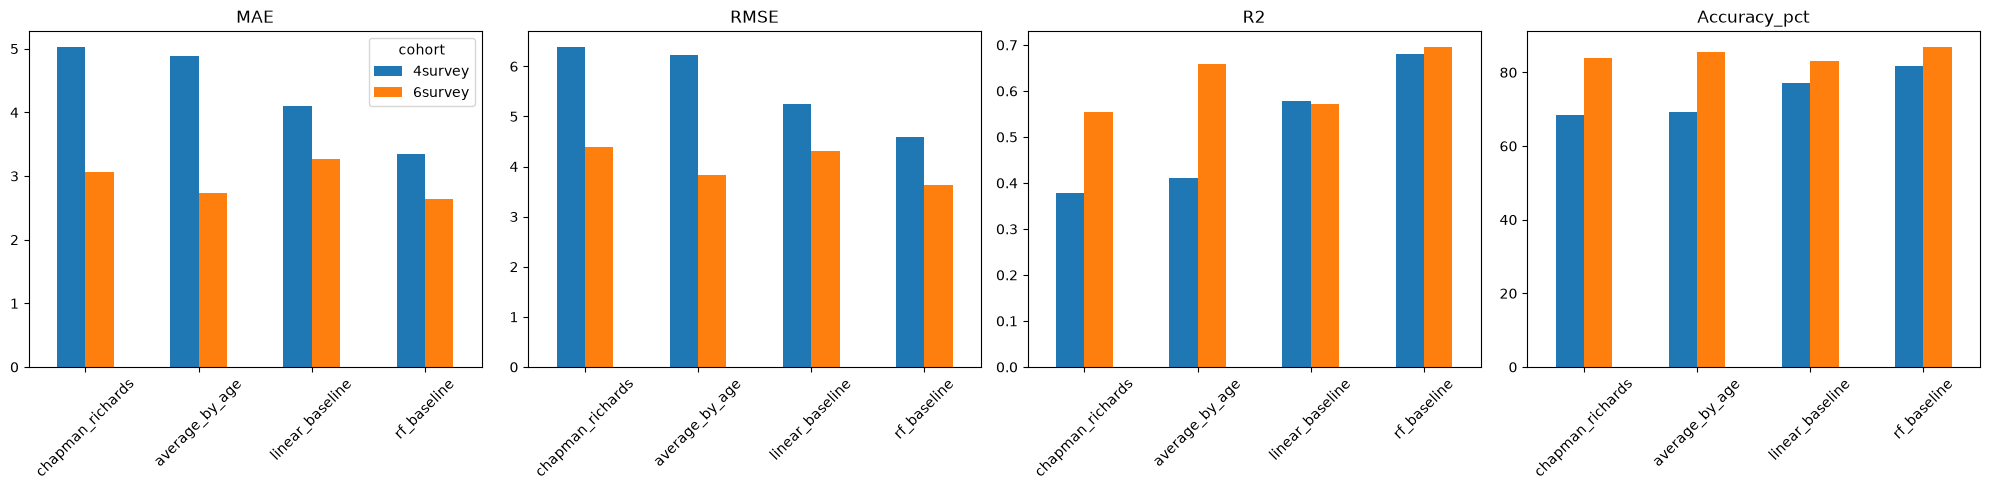

In [5]:
metrics_to_plot = ["MAE", "RMSE", "R2", "Accuracy_pct"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))

for ax, metric_name in zip(axes, metrics_to_plot):
    pivoted = summary_df.pivot(index="model", columns="cohort", values=metric_name).loc[MODEL_NAMES]
    pivoted.plot(kind="bar", ax=ax, legend=(metric_name == metrics_to_plot[0]))
    ax.set_title(metric_name)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 4. Predicted vs. observed, residuals, and error-by-age — per model, per cohort

Using `models/common/plotting.py` directly (the same functions available to every model script),
not reimplemented here.

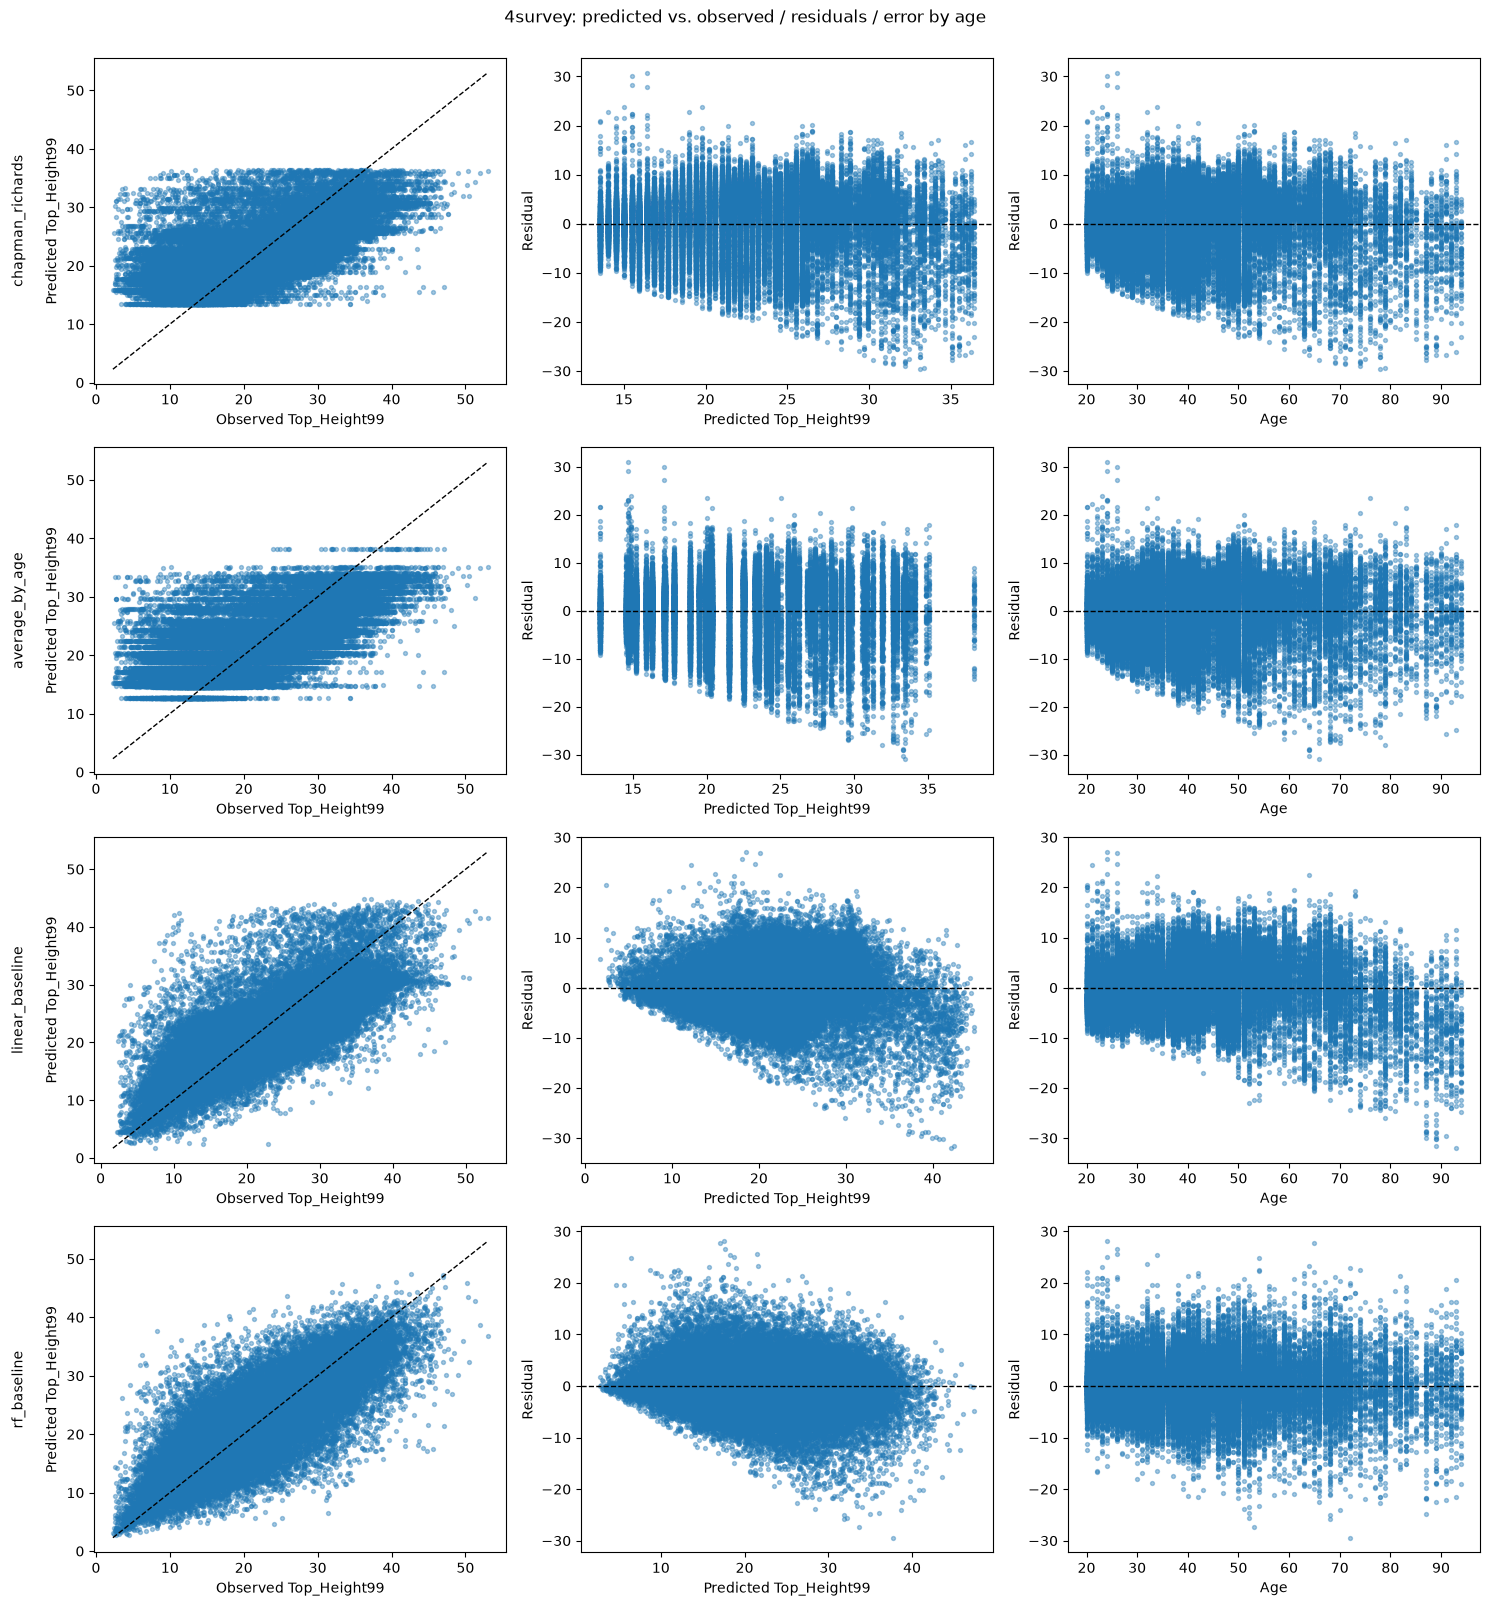

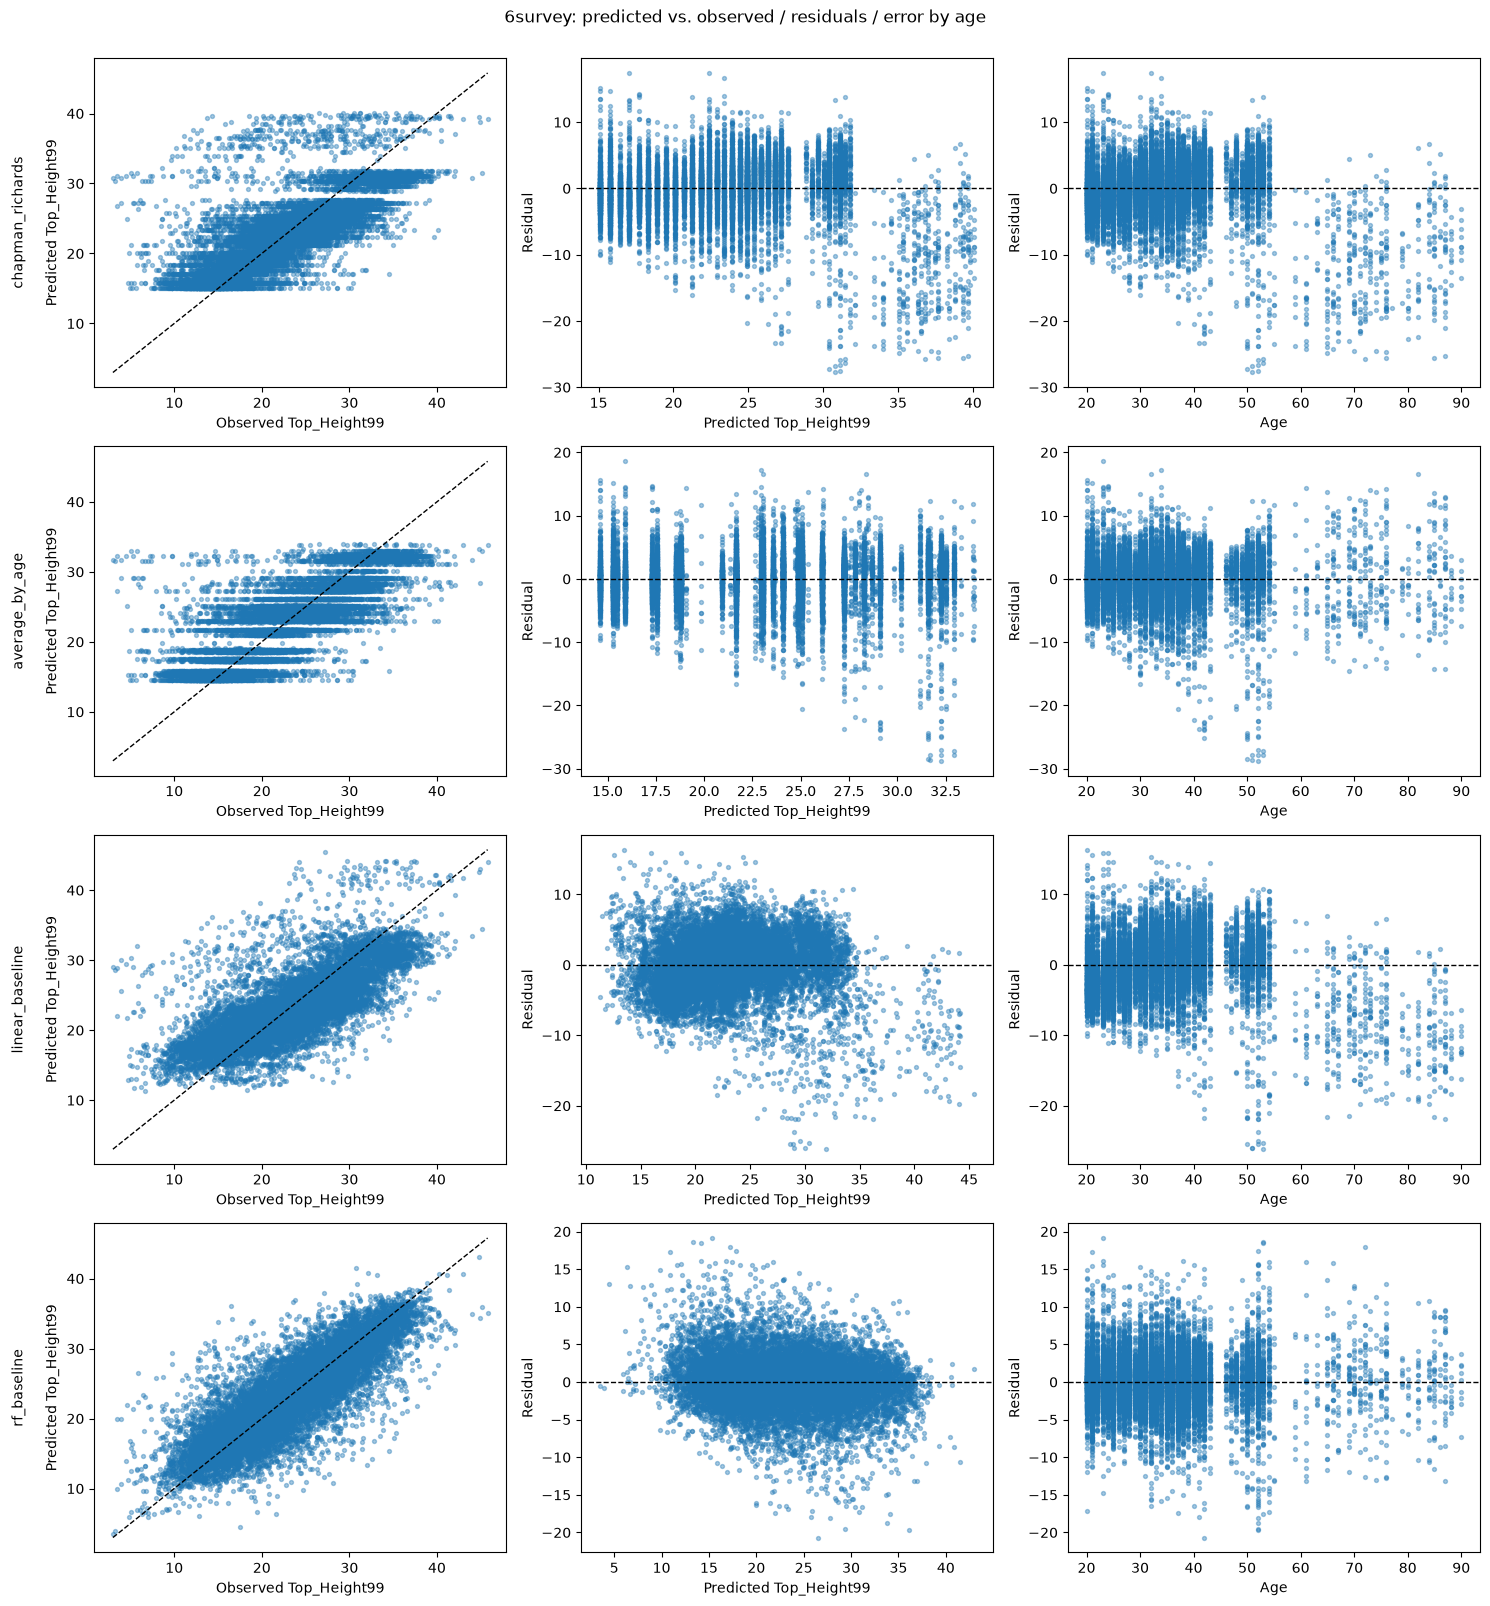

In [6]:
for cohort in COHORTS:
    fig, axes = plt.subplots(len(MODEL_NAMES), 3, figsize=(15, 4 * len(MODEL_NAMES)))
    fig.suptitle(f"{cohort}: predicted vs. observed / residuals / error by age", y=1.001)

    for row, model_name in enumerate(MODEL_NAMES):
        predictions_df = all_predictions[(model_name, cohort)]
        observed = predictions_df["observed_top_height"]
        predicted = predictions_df["predicted_top_height"]
        age = predictions_df["Age"]

        plot_predicted_vs_observed(observed, predicted, ax=axes[row, 0])
        plot_residuals(observed, predicted, ax=axes[row, 1])
        plot_error_by_age(age, observed, predicted, ax=axes[row, 2])

        axes[row, 0].set_ylabel(f"{model_name}\n\nPredicted Top_Height99")

    plt.tight_layout()
    plt.show()

## 5. Age-banded breakdown

MRE inflates on short/young plots since it divides by observed height, so a global MRE can look
worse than a model's real fit quality on mature plots — the age-banded view (from
`models/common/metrics.py`) separates that out.

In [7]:
age_band_rows = []
for cohort in COHORTS:
    for model_name in MODEL_NAMES:
        for band in all_metrics[(model_name, cohort)].get("age_bands", []):
            age_band_rows.append({
                "cohort": cohort,
                "model": model_name,
                "band": band["band"],
                "n_rows": band["n_rows"],
                "MAE": band["mae"],
                "RMSE": band["rmse"],
                "Bias": band["bias"],
                "MRE": band["mre"],
            })

age_band_df = pd.DataFrame(age_band_rows)
display(age_band_df.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "Bias": "{:.3f}", "MRE": "{:.3f}"}))

,cohort,model,band,n_rows,MAE,RMSE,Bias,MRE
0,4survey,chapman_richards,20-40,27686,4.173,5.276,-0.115,0.304
1,4survey,chapman_richards,40-60,16382,6.009,7.255,0.461,0.331
2,4survey,chapman_richards,60-80,4503,6.313,8.290,-0.289,0.329
3,4survey,chapman_richards,80+,1026,6.763,8.833,-3.476,0.300
4,4survey,average_by_age,20-40,27686,4.129,5.221,0.002,0.298
5,4survey,average_by_age,40-60,16382,5.790,7.110,0.122,0.324
6,4survey,average_by_age,60-80,4503,6.005,7.823,-0.229,0.310
7,4survey,average_by_age,80+,1026,5.992,7.550,-0.603,0.247
8,4survey,linear_baseline,20-40,27686,3.303,4.163,-0.380,0.212
9,4survey,linear_baseline,40-60,16382,4.702,5.688,1.156,0.235


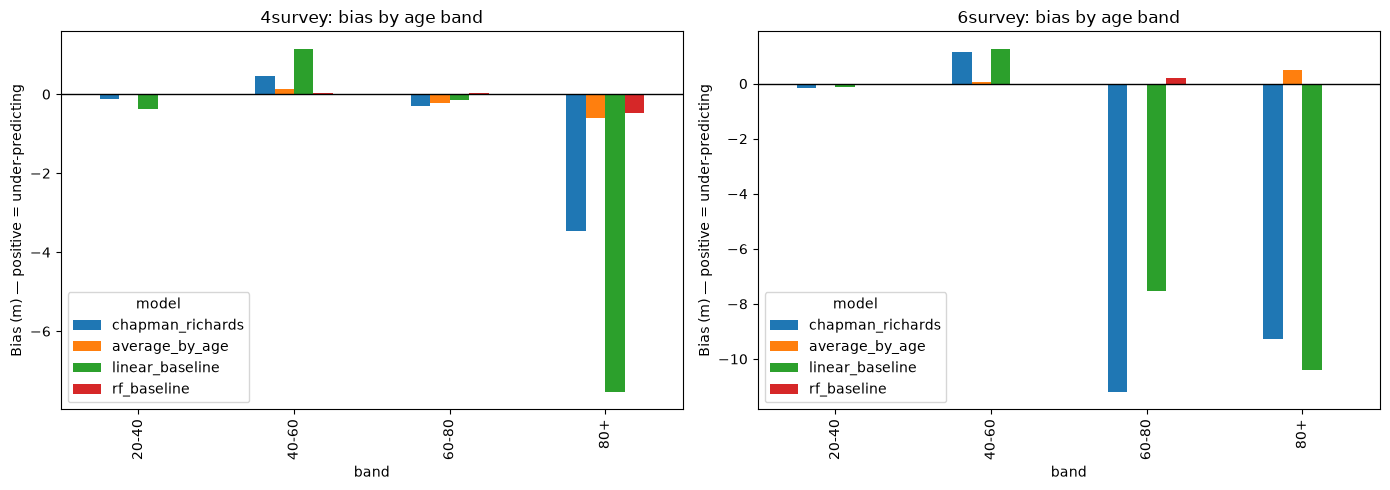

In [8]:
# Bias by age band is the clearest single view of where each model is
# systematically over- or under-predicting.
fig, axes = plt.subplots(1, len(COHORTS), figsize=(14, 5))

for ax, cohort in zip(axes, COHORTS):
    cohort_bands = age_band_df[age_band_df["cohort"] == cohort]
    pivoted = cohort_bands.pivot(index="band", columns="model", values="Bias")
    band_order = [b for b in ["20-40", "40-60", "60-80", "80+"] if b in pivoted.index]
    pivoted = pivoted.loc[band_order, MODEL_NAMES]

    pivoted.plot(kind="bar", ax=ax, color=[MODEL_COLORS[m] for m in MODEL_NAMES])
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{cohort}: bias by age band")
    ax.set_ylabel("Bias (m) — positive = under-predicting")

plt.tight_layout()
plt.show()

## 6. Chapman-Richards fitted parameters vs. prior dissertation

The only model here with directly interpretable, checkable fitted parameters.

In [9]:
PRIOR_CR_PARAMS = {"y_max": 46.1126, "k": 0.01866979, "p": 1.0175}

cr_param_rows = [{"cohort": "prior (Lynch, 2025)", **PRIOR_CR_PARAMS}]
for cohort in COHORTS:
    params_path = project_root / "outputs" / "chapman_richards" / cohort / "params.json"
    with open(params_path) as f:
        params = json.load(f)
    cr_param_rows.append({"cohort": cohort, "y_max": params["y_max"], "k": params["k"], "p": params["p"]})

cr_param_df = pd.DataFrame(cr_param_rows)
display(cr_param_df.style.format({"y_max": "{:.6f}", "k": "{:.8f}", "p": "{:.6f}"}))

,cohort,y_max,k,p
0,"prior (Lynch, 2025)",46.112600,0.01866979,1.017500
1,4survey,53.490917,0.01058176,0.830202
2,6survey,46.513191,0.02344434,1.146632


## 7. Progress so far

- **Data pipeline**: cleaned, balanced 4survey (71,766 plots) and 6survey (13,897 plots) Sitka
  cohorts exported from the raw GeoPackage, target `Top_Height99` (fallback `Top_Height95`),
  filters `Age >= 20` and yield class 2-50 applied before fitting.
- **Split infrastructure**: `plot_level_split()` (used by all four models here),
  `spatial_block_split()` (compartment-based, size-aware, asymmetric train-only buffering — see
  `data_exploration_gpkg/notebooks/spatial_temporal_split_visualisation.ipynb`), and
  `temporal_split()` — the latter two implemented and tested but not yet wired into a model.
- **Four baselines fitted and evaluated**, all on `plot_level_split` (no environmental features
  yet, so no spatial leakage risk at this stage): Chapman-Richards, average-by-age, linear
  regression, random forest.
- **Not started yet**: DNN, PINN, terrain/wind features, XGBoost + SHAP, spatial/temporal
  generalisation testing.

See `documentation/plans_md/Dissertation Plan v5 - 7th June.md` ("Implementation Status" section)
for the fuller narrative version of this.